In [1]:
%%writefile requirements.txt
joblib==1.3.2
flask==3.0.3
numpy==1.26.4
scikit-learn
pandas==2.1.4
matplotlib==3.8.0
seaborn
plotly==5.16.0
requests==2.31.0

Writing requirements.txt


In [2]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
df = pd.concat([X, pd.Series(y, name='target')], axis=1)
print('Features shape:', X.shape)
print('Target shape:', y.shape)
print('\nFeature names:', iris.feature_names)
print('Target names:', iris.target_names.tolist())
# Show a sample of the dataset
df.head()

Features shape: (150, 4)
Target shape: (150,)

Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa', 'versicolor', 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


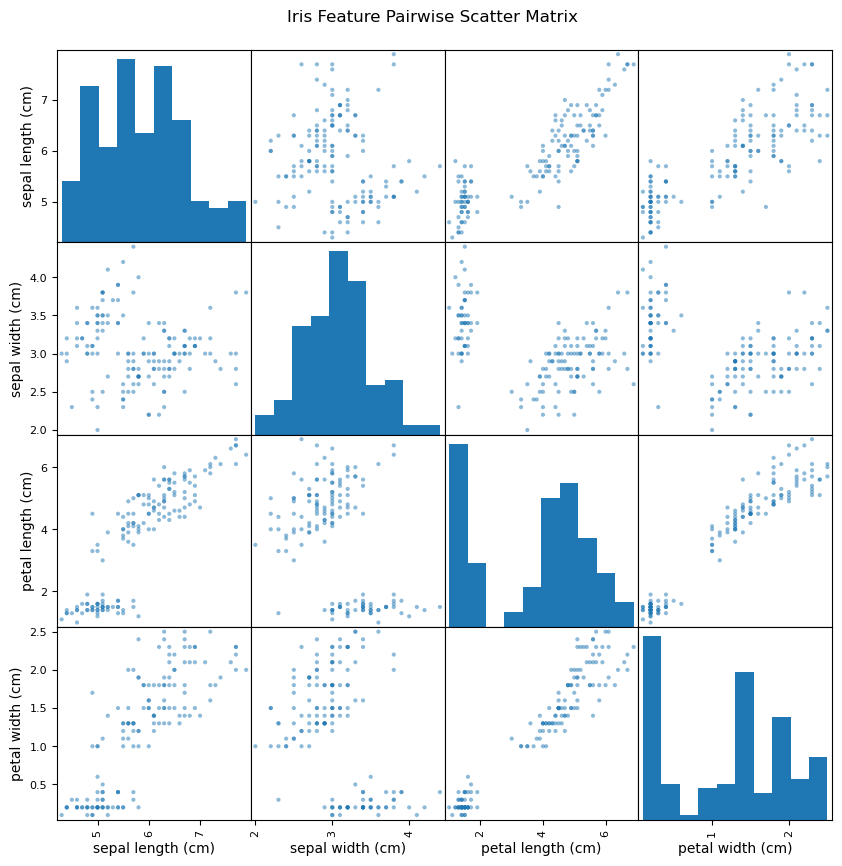

In [3]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
# Reduce text size for readability
pd.options.display.max_columns = None
# Scatter matrix (pairwise scatter plots)
axes = scatter_matrix(X, figsize=(10, 10), diagonal='hist')
# Improve layout
plt.suptitle('Iris Feature Pairwise Scatter Matrix', y=0.92)
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Train
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
# Predict & evaluate
y_pred = rf_classifier.predict(X_test)
acc = accuracy_score(y_test, y_pred)

RandomForest Test Accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion matrix:
 [[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


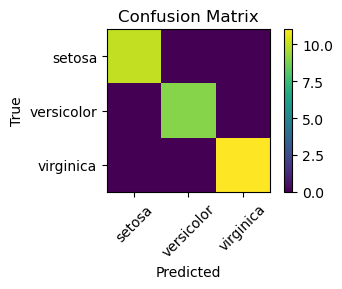

In [12]:
print(f'RandomForest Test Accuracy: {acc:.4f}\n')
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))
# Confusion matrix (plot)
cm = confusion_matrix(y_test, y_pred)
print('Confusion matrix:\n', cm)
import matplotlib.pyplot as plt
plt.figure(figsize=(4,3))
plt.imshow(cm, interpolation='nearest')
plt.title('Confusion Matrix')
plt.colorbar()
plt.xticks(range(len(iris.target_names)), iris.target_names, rotation=45)
plt.yticks(range(len(iris.target_names)), iris.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [2]:
import os, joblib, pickle, json
import numpy as np
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. Load the dataset and split it
iris = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris.data, iris.target, test_size=0.2, random_state=42)
X = iris.data  # Defined for calculating the min/max slider ranges below

# 2. Define and train the model (This fixes the 'rf' NameError)
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

# 3. Make predictions to generate y_pred
y_pred = rf.predict(X_test)

# 4. Create directories and save models
os.makedirs('models', exist_ok=True)

# Save joblib
joblib.dump(rf, 'models/iris_model.joblib')

# Save pickle
with open('models/iris_model.pickle', 'wb') as f:
    pickle.dump(rf, f)

# Save metadata
try:
    acc_val = float(accuracy_score(y_test, y_pred))
except Exception:
    acc_val = None

model_info = {
    'model_type': 'RandomForestClassifier',
    'accuracy': acc_val,
    'feature_names': list(iris.feature_names) if hasattr(iris.feature_names, 'tolist') else iris.feature_names,
    'target_names': iris.target_names.tolist() if hasattr(iris.target_names, 'tolist') else list(iris.target_names)
}

with open('models/model_info.json', 'w') as f:
    json.dump(model_info, f, indent=2)

# Define slider ranges using NumPy indexing since X is an array here
feature_ranges = {
    'sepal_length': {'min': float(np.min(X[:, 0])), 'max': float(np.max(X[:, 0]))},
    'sepal_width':  {'min': float(np.min(X[:, 1])), 'max': float(np.max(X[:, 1]))},
    'petal_length': {'min': float(np.min(X[:, 2])), 'max': float(np.max(X[:, 2]))},
    'petal_width':  {'min': float(np.min(X[:, 3])), 'max': float(np.max(X[:, 3]))},
}

with open('models/feature_ranges.json', 'w') as f:
    json.dump(feature_ranges, f, indent=2)

print('Saved: models/iris_model.joblib, models/iris_model.pickle, models/model_info.json, models/feature_ranges.json')


Saved: models/iris_model.joblib, models/iris_model.pickle, models/model_info.json, models/feature_ranges.json


In [3]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib
import pickle
import json
from PIL import Image
import io
# Set page config
st.set_page_config(
 page_title="Iris Flower Classifier",
 page_icon="🌸",
 layout="wide",
 initial_sidebar_state="expanded"
)
# Custom CSS
st.markdown("""
<style>
 .main-header {
 font-size: 3rem;
 color: #6a0dad;
 text-align: center;
 margin-bottom: 2rem;
 }
 .prediction-card {
 background-color: #f0f8ff;
 padding: 2rem;
 border-radius: 10px;
 border-left: 5px solid #6a0dad;
 margin: 1rem 0;
 }
 .feature-slider {
 margin: 1.5rem 0;
 }
 .confidence-bar {
 height: 20px;
 background-color: #e0e0e0;
 border-radius: 10px;
 margin: 0.5rem 0;
 }
 .confidence-fill {
 height: 100%;
 border-radius: 10px;
 background: linear-gradient(90deg, #ff6b6b, #4ecdc4);
 text-align: center;
 color: white;
 font-weight: bold;
 }
</style>
""", unsafe_allow_html=True)
# Load model and metadata
@st.cache_resource
def load_model(format_type='joblib'):
 """Load the model from the specified format"""
 try:
 if format_type == 'joblib':
 model = joblib.load('models/iris_model.joblib')
 elif format_type == 'pickle':
 with open('models/iris_model.pickle', 'rb') as f:
 model = pickle.load(f)
 return model
 except Exception as e:
   st.error(f"Error loading model: {e}")
 return None
@st.cache_resource
def load_model_info():
 """Load model metadata"""
 try:
 with open('models/model_info.json', 'r') as f:
 return json.load(f)
 except Exception as e:
 st.error(f"Error loading model info: {e}")
 return None
@st.cache_resource
def load_feature_ranges():
 """Load feature ranges for sliders"""
 try:
 with open('models/feature_ranges.json', 'r') as f:
 return json.load(f)
 except:
 # Default ranges if file doesn't exist
 return {
 'sepal_length': {'min': 4.0, 'max': 8.0, 'default': 5.8},
 'sepal_width': {'min': 2.0, 'max': 4.5, 'default': 3.0},
 'petal_length': {'min': 1.0, 'max': 7.0, 'default': 4.0},
 'petal_width': {'min': 0.1, 'max': 2.5, 'default': 1.2}
 }
# Load data
model_info = load_model_info()
feature_ranges = load_feature_ranges()
model = load_model('joblib') # Default to joblib
# Sidebar
with st.sidebar:
 st.title("⚙️ Settings")
 # Model format selection
 model_format = st.radio(
 "Model Format",
 ["joblib", "pickle"],
 help="Choose which serialized model format to use for predictions"
 )
 # Reload model button
 if st.button("🔄 Reload Model"):
 model = load_model(model_format)
 if model:
 st.success(f"Model loaded from {model_format} format!")
 st.divider()
 # Model info
 st.subheader("📊 Model Information")
 if model_info:
 st.write(f"**Type:** {model_info.get('model_type', 'RandomForest')}")
 st.write(f"**Accuracy:** {model_info.get('accuracy', 0.96):.1%}")
 st.write(f"**Features:** {len(model_info.get('feature_names', []))}")
 st.write(f"**Classes:** {len(model_info.get('target_names', []))}")
 st.divider()
# Quick actions
 st.subheader("🚀 Quick Actions")
 if st.button("📊 Show Dataset Info"):
 st.session_state.show_dataset_info = True
 if st.button("🎯 Make Prediction"):
 st.session_state.make_prediction = True
# Main content
st.markdown('<h1 class="main-header">🌸 Iris Flower Classification</h1>', unsafe_allow_html=T
# Description
st.markdown("""
This app predicts the species of an Iris flower based on its measurements using a machine lear
Adjust the sliders below to input the flower's characteristics and see the prediction!
""")
# Create input form
col1, col2 = st.columns([2, 1])
with col1:
 st.header("📝 Input Features")
 # Create sliders based on feature ranges
 sepal_length = st.slider(
 "**Sepal Length (cm)**",
 min_value=float(feature_ranges['sepal_length']['min']),
 max_value=float(feature_ranges['sepal_length']['max']),
 value=float(feature_ranges['sepal_length']['default']),
 step=0.1,
 help="Length of the sepal in centimeters"
 )
 sepal_width = st.slider(
 "**Sepal Width (cm)**",
 min_value=float(feature_ranges['sepal_width']['min']),
 max_value=float(feature_ranges['sepal_width']['max']),
 value=float(feature_ranges['sepal_width']['default']),
 step=0.1,
 help="Width of the sepal in centimeters"
 )
 petal_length = st.slider(
 "**Petal Length (cm)**",
 min_value=float(feature_ranges['petal_length']['min']),
 max_value=float(feature_ranges['petal_length']['max']),
 value=float(feature_ranges['petal_length']['default']),
 step=0.1,
 help="Length of the petal in centimeters"
 )
 petal_width = st.slider(
 "**Petal Width (cm)**",
 min_value=float(feature_ranges['petal_width']['min']),
 max_value=float(feature_ranges['petal_width']['max']),
 value=float(feature_ranges['petal_width']['default']),
 step=0.1,
 help="Width of the petal in centimeters"
 )
with col2:
 st.header("📊 Current Values")
# Display current feature values
 features_df = pd.DataFrame({
 'Feature': ['Sepal Length', 'Sepal Width', 'Petal Length', 'Petal Width'],
 'Value (cm)': [sepal_length, sepal_width, petal_length, petal_width]
 })
 st.dataframe(
 features_df,
 hide_index=True,
 use_container_width=True
 )
 # Create feature array for prediction
 input_features = np.array([[sepal_length, sepal_width, petal_length, petal_width]])
# Prediction button
if st.button("🎯 Predict Species", type="primary", use_container_width=True):
 if model is not None and model_info is not None:
 try:
 # Make prediction
 prediction = model.predict(input_features)
 prediction_proba = model.predict_proba(input_features)[0]
 # Get predicted class name
 predicted_class = model_info['target_names'][prediction[0]]
 # Display results
 st.markdown('<div class="prediction-card">', unsafe_allow_html=True)
 st.markdown(f"### 📋 Prediction Result")
 st.markdown(f"**Predicted Species:** **{predicted_class}**")
 # Show confidence scores with progress bars
 st.markdown("### 📈 Confidence Scores")
 for i, prob in enumerate(prediction_proba):
 species = model_info['target_names'][i]
 percentage = prob * 100
 col_prog, col_text = st.columns([3, 1])
 with col_prog:
 st.markdown(f"""
 <div class="confidence-bar">
 <div class="confidence-fill" style="width: {percentage}%;">
 {percentage:.1f}%
 </div>
 </div>
 """, unsafe_allow_html=True)
 with col_text:
 st.write(f"**{species}**")
 st.markdown('</div>', unsafe_allow_html=True)
 except Exception as e:
 st.error(f"❌ Error making prediction: {e}")
 else:
 st.error("❌ Model could not be loaded. Please check if the model files exist.")
# Additional information
with st.expander("📚 About the Iris Dataset"):
 st.markdown("""
 The Iris flower dataset is a classic dataset in machine learning and statistics introduced
 **Dataset Characteristics:**
 - 150 samples (50 per class)
 - 4 features per sample
 - 3 classes (species)
 **Species:**
 - **Iris Setosa**
 - **Iris Versicolor**
 - **Iris Virginica**
 **Features:**
 1. Sepal length (cm)
 2. Sepal width (cm)
 3. Petal length (cm)
 4. Petal width (cm)
 This model uses a **Random Forest classifier** with an accuracy of approximately 96%.
 """)
# Footer
st.markdown("---")
st.markdown("""
<div style='text-align: center'>
 <p>Built with Streamlit and Scikit-learn</p>
</div>
""", unsafe_allow_html=True)

Writing app.py
